Dataset

In [51]:
# Install Library

!pip install -q datasets sentence-transformers faiss-cpu pandas numpy tqdm

In [52]:
# Import Library

from datasets import load_dataset
from sentence_transformers import SentenceTransformer
import faiss
import numpy as np
import pandas as pd
from tqdm.auto import tqdm
import os

In [53]:
# Load Dataset IDK-MRC

from datasets import load_dataset

dataset = load_dataset("rifkiaputri/idk-mrc")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [54]:
print(dataset)
print("\nSplit yang tersedia:")
print(dataset.keys())

DatasetDict({
    train: Dataset({
        features: ['qas', 'context'],
        num_rows: 3659
    })
    validation: Dataset({
        features: ['qas', 'context'],
        num_rows: 358
    })
    test: Dataset({
        features: ['qas', 'context'],
        num_rows: 378
    })
})

Split yang tersedia:
dict_keys(['train', 'validation', 'test'])
DatasetDict({
    train: Dataset({
        features: ['qas', 'context'],
        num_rows: 3659
    })
    validation: Dataset({
        features: ['qas', 'context'],
        num_rows: 358
    })
    test: Dataset({
        features: ['qas', 'context'],
        num_rows: 378
    })
})

Split yang tersedia:
dict_keys(['train', 'validation', 'test'])


In [55]:
# Cek Struktur Dataset

for split in dataset.keys():
    print("=" * 80)
    print("SPLIT:", split)
    print("Kolom:", dataset[split].column_names)
    print("Contoh data pertama:")
    print(dataset[split][0])

SPLIT: train
Kolom: ['qas', 'context']
Contoh data pertama:
{'qas': [{'answers': [{'answer_start': 26, 'text': 'Pasuruan, Jawa Timur'}], 'id': 'indonesian-1653118927826418646-2', 'is_impossible': False, 'question': 'dimanakah  Dr. Ernest François Eugène Douwes Dekker dilahirkan?'}, {'answers': [], 'id': 'indonesian-2988585593205955820-unans-h-2', 'is_impossible': True, 'question': 'di manakah  Dr. Ernest François Eugène Douwes Dekker meninggal?'}], 'context': 'Douwes Dekker terlahir di Pasuruan, Jawa Timur, pada tanggal 8 Oktober 1879, sebagaimana yang dia tulis pada riwayat hidup singkat saat mendaftar di Universitas Zurich, September 1913. Ayahnya, Auguste Henri Edoeard Douwes Dekker, adalah seorang agen di bank kelas kakap Nederlandsch Indisch Escomptobank. Auguste ayahnya, memiliki darah Belanda dari ayahnya, Jan (adik Eduard Douwes Dekker) dan dari ibunya, Louise Bousquet. Sementara itu, ibu Douwes Dekker, Louisa Neumann, lahir di Pekalongan, Jawa Tengah, dari pasangan Jerman-Jawa

### Preprocessing

In [56]:
# Pilih Split Dataset

if "train" in dataset:
    split_name = "train"
else:
    split_name = list(dataset.keys())[0]

data = dataset[split_name]

print("Split yang dipakai:", split_name)
print("Jumlah data:", len(data))
print("Kolom:", data.column_names)

Split yang dipakai: train
Jumlah data: 3659
Kolom: ['qas', 'context']
Split yang dipakai: train
Jumlah data: 3659
Kolom: ['qas', 'context']


In [57]:
# Validasi Struktur Dataset

columns = data.column_names
print("Kolom dataset:", columns)

if "context" not in columns or "qas" not in columns:
    raise ValueError("Dataset ini tidak punya struktur IDK-MRC yang berisi 'context' dan 'qas'.")

print("\nContoh data pertama:")
print(data[0])

Kolom dataset: ['qas', 'context']

Contoh data pertama:
{'qas': [{'answers': [{'answer_start': 26, 'text': 'Pasuruan, Jawa Timur'}], 'id': 'indonesian-1653118927826418646-2', 'is_impossible': False, 'question': 'dimanakah  Dr. Ernest François Eugène Douwes Dekker dilahirkan?'}, {'answers': [], 'id': 'indonesian-2988585593205955820-unans-h-2', 'is_impossible': True, 'question': 'di manakah  Dr. Ernest François Eugène Douwes Dekker meninggal?'}], 'context': 'Douwes Dekker terlahir di Pasuruan, Jawa Timur, pada tanggal 8 Oktober 1879, sebagaimana yang dia tulis pada riwayat hidup singkat saat mendaftar di Universitas Zurich, September 1913. Ayahnya, Auguste Henri Edoeard Douwes Dekker, adalah seorang agen di bank kelas kakap Nederlandsch Indisch Escomptobank. Auguste ayahnya, memiliki darah Belanda dari ayahnya, Jan (adik Eduard Douwes Dekker) dan dari ibunya, Louise Bousquet. Sementara itu, ibu Douwes Dekker, Louisa Neumann, lahir di Pekalongan, Jawa Tengah, dari pasangan Jerman-Jawa.[1]

In [58]:
# Fungsi untuk Membersihkan Teks

def clean_text(text):
    """
    Membersihkan teks sederhana:
    - mengubah None menjadi string kosong
    - mengubah list/dict menjadi string
    - menghapus spasi berlebih
    """
    if text is None:
        return ""

    if isinstance(text, list):
        text = " ".join([str(x) for x in text])

    if isinstance(text, dict):
        text = str(text)

    text = str(text)
    text = " ".join(text.split())
    return text

In [59]:
# Flatten qas menjadi DataFrame QA

# Satu context bisa punya banyak question-answer.
# Format akhir:
# question | answer | context | gold_doc_id | is_impossible

qa_rows = []
documents = []

for doc_id, item in enumerate(data):
    context = clean_text(item["context"])

    documents.append({
        "doc_id": doc_id,
        "text": context
    })

    for qa in item["qas"]:
        question = clean_text(qa.get("question", ""))
        is_impossible = qa.get("is_impossible", False)
        answers_raw = qa.get("answers", [])

        answer_texts = []
        answer_starts = []

        # Struktur answers biasanya list of dict
        if isinstance(answers_raw, list):
            for ans in answers_raw:
                if isinstance(ans, dict):
                    answer_texts.append(clean_text(ans.get("text", "")))
                    answer_starts.append(ans.get("answer_start", None))
                else:
                    answer_texts.append(clean_text(ans))
                    answer_starts.append(None)

        # Antisipasi kalau answers berbentuk dict
        elif isinstance(answers_raw, dict):
            texts = answers_raw.get("text", [])
            starts = answers_raw.get("answer_start", [])

            if isinstance(texts, list):
                answer_texts = [clean_text(t) for t in texts]
            else:
                answer_texts = [clean_text(texts)]

            if isinstance(starts, list):
                answer_starts = starts
            else:
                answer_starts = [starts]

        if len(answer_texts) > 0:
            answer = answer_texts[0]
        else:
            answer = "Tidak diketahui"

        qa_rows.append({
            "question_id": qa.get("id", ""),
            "question": question,
            "answer": answer,
            "all_answers": answer_texts,
            "answer_starts": answer_starts,
            "is_impossible": is_impossible,
            "gold_doc_id": doc_id,
            "context": context
        })

qa_df = pd.DataFrame(qa_rows)
documents_df = pd.DataFrame(documents)

print("Jumlah dokumen/context:", len(documents_df))
print("Jumlah pasangan question-answer:", len(qa_df))

print("\nContoh QA:")
display(qa_df.head())

print("\nContoh dokumen:")
display(documents_df.head())

Jumlah dokumen/context: 3659
Jumlah pasangan question-answer: 9332

Contoh QA:


,question_id,question,answer,all_answers,answer_starts,is_impossible,gold_doc_id,context
0,indonesian-1653118927826418646-2,dimanakah Dr. Ernest François Eugène Douwes De...,"Pasuruan, Jawa Timur","[Pasuruan, Jawa Timur]",[26],False,0,"Douwes Dekker terlahir di Pasuruan, Jawa Timur..."
1,indonesian-2988585593205955820-unans-h-2,di manakah Dr. Ernest François Eugène Douwes D...,Tidak diketahui,[],[],True,0,"Douwes Dekker terlahir di Pasuruan, Jawa Timur..."
2,indonesian--6681782391154035358-9,Kapan PBB mulai terbentuk ?,24 Oktober 1945,[24 Oktober 1945],[360],False,1,Sebagai tindak lanjut Atlantic Charter tersebu...
3,indonesian-7178095139251802211-unans-h-2,Kapan PBB dibubarkan?,Tidak diketahui,[],[],True,1,Sebagai tindak lanjut Atlantic Charter tersebu...
4,indonesian--7923158717065963850-0,Siapakah pendiri PBB?,51 negara anggota,[51 negara anggota],[352],False,2,"Perserikatan Bangsa-Bangsa (PBB, English: Unit..."



Contoh dokumen:


,doc_id,text
0,0,"Douwes Dekker terlahir di Pasuruan, Jawa Timur..."
1,1,Sebagai tindak lanjut Atlantic Charter tersebu...
2,2,"Perserikatan Bangsa-Bangsa (PBB, English: Unit..."
3,3,"James Hepburn (skt. 1534– 14 April 1578), Adip..."
4,4,Jamie Richard Vardy (lahir dengan nama Gill; 1...


Jumlah dokumen/context: 3659
Jumlah pasangan question-answer: 9332

Contoh QA:


,question_id,question,answer,all_answers,answer_starts,is_impossible,gold_doc_id,context
0,indonesian-1653118927826418646-2,dimanakah Dr. Ernest François Eugène Douwes De...,"Pasuruan, Jawa Timur","[Pasuruan, Jawa Timur]",[26],False,0,"Douwes Dekker terlahir di Pasuruan, Jawa Timur..."
1,indonesian-2988585593205955820-unans-h-2,di manakah Dr. Ernest François Eugène Douwes D...,Tidak diketahui,[],[],True,0,"Douwes Dekker terlahir di Pasuruan, Jawa Timur..."
2,indonesian--6681782391154035358-9,Kapan PBB mulai terbentuk ?,24 Oktober 1945,[24 Oktober 1945],[360],False,1,Sebagai tindak lanjut Atlantic Charter tersebu...
3,indonesian-7178095139251802211-unans-h-2,Kapan PBB dibubarkan?,Tidak diketahui,[],[],True,1,Sebagai tindak lanjut Atlantic Charter tersebu...
4,indonesian--7923158717065963850-0,Siapakah pendiri PBB?,51 negara anggota,[51 negara anggota],[352],False,2,"Perserikatan Bangsa-Bangsa (PBB, English: Unit..."



Contoh dokumen:


,doc_id,text
0,0,"Douwes Dekker terlahir di Pasuruan, Jawa Timur..."
1,1,Sebagai tindak lanjut Atlantic Charter tersebu...
2,2,"Perserikatan Bangsa-Bangsa (PBB, English: Unit..."
3,3,"James Hepburn (skt. 1534– 14 April 1578), Adip..."
4,4,Jamie Richard Vardy (lahir dengan nama Gill; 1...


In [60]:
# Pisahkan Answerable dan Unanswerable Questions

answerable_qa_df = qa_df[qa_df["is_impossible"] == False].reset_index(drop=True)
unanswerable_qa_df = qa_df[qa_df["is_impossible"] == True].reset_index(drop=True)

print("Jumlah semua QA:", len(qa_df))
print("Jumlah answerable QA:", len(answerable_qa_df))
print("Jumlah unanswerable QA:", len(unanswerable_qa_df))

# Untuk eksperimen retrieval awal, pakai answerable question
eval_df = answerable_qa_df

Jumlah semua QA: 9332
Jumlah answerable QA: 5042
Jumlah unanswerable QA: 4290
Jumlah semua QA: 9332
Jumlah answerable QA: 5042
Jumlah unanswerable QA: 4290


In [61]:
# Siapkan Variable Utama

questions = qa_df["question"].tolist()
answers = qa_df["answer"].tolist()
contexts = qa_df["context"].tolist()

print("Jumlah questions:", len(questions))
print("Jumlah answers  :", len(answers))
print("Jumlah contexts :", len(contexts))

print("\nContoh question:")
print(questions[0])

print("\nContoh answer:")
print(answers[0])

print("\nGold doc id:")
print(qa_df.iloc[0]["gold_doc_id"])

print("\nContoh context:")
print(contexts[0][:500])

Jumlah questions: 9332
Jumlah answers  : 9332
Jumlah contexts : 9332

Contoh question:
dimanakah Dr. Ernest François Eugène Douwes Dekker dilahirkan?

Contoh answer:
Pasuruan, Jawa Timur

Gold doc id:
0

Contoh context:
Douwes Dekker terlahir di Pasuruan, Jawa Timur, pada tanggal 8 Oktober 1879, sebagaimana yang dia tulis pada riwayat hidup singkat saat mendaftar di Universitas Zurich, September 1913. Ayahnya, Auguste Henri Edoeard Douwes Dekker, adalah seorang agen di bank kelas kakap Nederlandsch Indisch Escomptobank. Auguste ayahnya, memiliki darah Belanda dari ayahnya, Jan (adik Eduard Douwes Dekker) dan dari ibunya, Louise Bousquet. Sementara itu, ibu Douwes Dekker, Louisa Neumann, lahir di Pekalongan, Jaw
Jumlah questions: 9332
Jumlah answers  : 9332
Jumlah contexts : 9332

Contoh question:
dimanakah Dr. Ernest François Eugène Douwes Dekker dilahirkan?

Contoh answer:
Pasuruan, Jawa Timur

Gold doc id:
0

Contoh context:
Douwes Dekker terlahir di Pasuruan, Jawa Timur, pada tangga

In [62]:
# Corpus Dokumen untuk Retriever

doc_texts = documents_df["text"].tolist()

print("Jumlah corpus dokumen:", len(doc_texts))
print(doc_texts[0][:500])

Jumlah corpus dokumen: 3659
Douwes Dekker terlahir di Pasuruan, Jawa Timur, pada tanggal 8 Oktober 1879, sebagaimana yang dia tulis pada riwayat hidup singkat saat mendaftar di Universitas Zurich, September 1913. Ayahnya, Auguste Henri Edoeard Douwes Dekker, adalah seorang agen di bank kelas kakap Nederlandsch Indisch Escomptobank. Auguste ayahnya, memiliki darah Belanda dari ayahnya, Jan (adik Eduard Douwes Dekker) dan dari ibunya, Louise Bousquet. Sementara itu, ibu Douwes Dekker, Louisa Neumann, lahir di Pekalongan, Jaw
Jumlah corpus dokumen: 3659
Douwes Dekker terlahir di Pasuruan, Jawa Timur, pada tanggal 8 Oktober 1879, sebagaimana yang dia tulis pada riwayat hidup singkat saat mendaftar di Universitas Zurich, September 1913. Ayahnya, Auguste Henri Edoeard Douwes Dekker, adalah seorang agen di bank kelas kakap Nederlandsch Indisch Escomptobank. Auguste ayahnya, memiliki darah Belanda dari ayahnya, Jan (adik Eduard Douwes Dekker) dan dari ibunya, Louise Bousquet. Sementara itu, ib

In [63]:
# Load Embedding Model

embedding_model_name = "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"
embedder = SentenceTransformer(embedding_model_name)

print("Embedding model:", embedding_model_name)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Embedding model: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Embedding model: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2


In [64]:
# Encode Dokumen menjadi Embedding

doc_embeddings = embedder.encode(
    doc_texts,
    convert_to_numpy=True,
    show_progress_bar=True,
    normalize_embeddings=True
)

print("Shape embeddings:", doc_embeddings.shape)

Batches:   0%|          | 0/115 [00:00<?, ?it/s]

Shape embeddings: (3659, 384)


Batches:   0%|          | 0/115 [00:00<?, ?it/s]

Shape embeddings: (3659, 384)


In [65]:
# Buat FAISS Index

# Karena embedding sudah dinormalisasi, IndexFlatIP bisa dipakai
# sebagai cosine similarity.

embedding_dim = doc_embeddings.shape[1]

index = faiss.IndexFlatIP(embedding_dim)
index.add(doc_embeddings)

print("Jumlah dokumen dalam FAISS index:", index.ntotal)

Jumlah dokumen dalam FAISS index: 3659
Jumlah dokumen dalam FAISS index: 3659


In [66]:
# Fungsi Retriever

def retrieve(query, top_k=5):
    """
    Mengambil top-k dokumen paling relevan berdasarkan query.
    """

    query = clean_text(query)

    # Supaya top_k tidak melebihi jumlah dokumen
    top_k = min(top_k, index.ntotal)

    query_embedding = embedder.encode(
        [query],
        convert_to_numpy=True,
        normalize_embeddings=True
    )

    scores, indices = index.search(query_embedding, top_k)

    results = []

    for rank, idx in enumerate(indices[0]):
        idx = int(idx)

        results.append({
            "rank": rank + 1,
            "doc_id": int(documents_df.iloc[idx]["doc_id"]),
            "score": float(scores[0][rank]),
            "text": documents_df.iloc[idx]["text"]
        })

    return results

### Retrieval Test

In [67]:
# Test Retrieval Top-5

sample_question = questions[0]
sample_answer = answers[0]
sample_gold_doc_id = qa_df.iloc[0]["gold_doc_id"]

print("Question:")
print(sample_question)

print("\nGround Truth Answer:")
print(sample_answer)

print("\nGold Doc ID:")
print(sample_gold_doc_id)

retrieved_docs = retrieve(sample_question, top_k=5)

print("\nHasil Retrieval Top-5:")
for doc in retrieved_docs:
    print("=" * 80)
    print(f"Rank  : {doc['rank']}")
    print(f"Doc ID: {doc['doc_id']}")
    print(f"Score : {doc['score']:.4f}")
    print("Text  :", doc["text"][:700])

Question:
dimanakah Dr. Ernest François Eugène Douwes Dekker dilahirkan?

Ground Truth Answer:
Pasuruan, Jawa Timur

Gold Doc ID:
0

Hasil Retrieval Top-5:
Rank  : 1
Doc ID: 0
Score : 0.7606
Text  : Douwes Dekker terlahir di Pasuruan, Jawa Timur, pada tanggal 8 Oktober 1879, sebagaimana yang dia tulis pada riwayat hidup singkat saat mendaftar di Universitas Zurich, September 1913. Ayahnya, Auguste Henri Edoeard Douwes Dekker, adalah seorang agen di bank kelas kakap Nederlandsch Indisch Escomptobank. Auguste ayahnya, memiliki darah Belanda dari ayahnya, Jan (adik Eduard Douwes Dekker) dan dari ibunya, Louise Bousquet. Sementara itu, ibu Douwes Dekker, Louisa Neumann, lahir di Pekalongan, Jawa Tengah, dari pasangan Jerman-Jawa.[1] Dia terlahir sebagai anak ke-3 dari 4 bersaudara, dan keluarganya pun sering berpindah-pindah. Saudaranya yang perempuan dan laki-laki, yakni Adeline (1876) dan
Rank  : 2
Doc ID: 2985
Score : 0.5835
Text  : Desiderius Erasmus dilaporkan lahir di Rotterdam pada 

In [68]:
# Test Variasi Top-K: K = 1, 3, 5, 10

sample_question = questions[0]
sample_answer = answers[0]
sample_gold_doc_id = qa_df.iloc[0]["gold_doc_id"]

print("Question:")
print(sample_question)

print("\nGround Truth Answer:")
print(sample_answer)

print("\nGold Doc ID:")
print(sample_gold_doc_id)

for k in [1, 3, 5, 10]:
    docs = retrieve(sample_question, top_k=k)

    retrieved_doc_ids = [doc["doc_id"] for doc in docs]
    retrieval_hit = sample_gold_doc_id in retrieved_doc_ids

    print("\n" + "=" * 80)
    print(f"TOP-{k} RETRIEVAL RESULT")
    print("Retrieved Doc IDs:", retrieved_doc_ids)
    print("Retrieval Hit:", retrieval_hit)
    print("=" * 80)

    for doc in docs:
        print(f"[{doc['rank']}] doc_id={doc['doc_id']} | score={doc['score']:.4f}")
        print(doc["text"][:500])
        print("-" * 80)

Question:
dimanakah Dr. Ernest François Eugène Douwes Dekker dilahirkan?

Ground Truth Answer:
Pasuruan, Jawa Timur

Gold Doc ID:
0

TOP-1 RETRIEVAL RESULT
Retrieved Doc IDs: [0]
Retrieval Hit: True
[1] doc_id=0 | score=0.7606
Douwes Dekker terlahir di Pasuruan, Jawa Timur, pada tanggal 8 Oktober 1879, sebagaimana yang dia tulis pada riwayat hidup singkat saat mendaftar di Universitas Zurich, September 1913. Ayahnya, Auguste Henri Edoeard Douwes Dekker, adalah seorang agen di bank kelas kakap Nederlandsch Indisch Escomptobank. Auguste ayahnya, memiliki darah Belanda dari ayahnya, Jan (adik Eduard Douwes Dekker) dan dari ibunya, Louise Bousquet. Sementara itu, ibu Douwes Dekker, Louisa Neumann, lahir di Pekalongan, Jaw
--------------------------------------------------------------------------------

TOP-3 RETRIEVAL RESULT
Retrieved Doc IDs: [0, 2985, 2516]
Retrieval Hit: True
[1] doc_id=0 | score=0.7606
Douwes Dekker terlahir di Pasuruan, Jawa Timur, pada tanggal 8 Oktober 1879, sebagai

In [69]:
# Format Context untuk Prompt Generator

def format_context_for_prompt(retrieved_docs):
    """
    Mengubah hasil retrieval menjadi format konteks untuk prompt generator.
    """

    formatted_contexts = []

    for doc in retrieved_docs:
        rank = doc["rank"]
        text = doc["text"]
        formatted_contexts.append(f"[{rank}] {text}")

    return "\n\n".join(formatted_contexts)


def get_rag_context(query, top_k=5):
    """
    Fungsi utama yang akan dipakai teman bagian generator.
    """

    retrieved_docs = retrieve(query, top_k=top_k)
    formatted_context = format_context_for_prompt(retrieved_docs)

    return retrieved_docs, formatted_context


# Test format context
retrieved_docs, formatted_context = get_rag_context(sample_question, top_k=3)

print("Formatted Context:")
print(formatted_context[:1500])

Formatted Context:
[1] Douwes Dekker terlahir di Pasuruan, Jawa Timur, pada tanggal 8 Oktober 1879, sebagaimana yang dia tulis pada riwayat hidup singkat saat mendaftar di Universitas Zurich, September 1913. Ayahnya, Auguste Henri Edoeard Douwes Dekker, adalah seorang agen di bank kelas kakap Nederlandsch Indisch Escomptobank. Auguste ayahnya, memiliki darah Belanda dari ayahnya, Jan (adik Eduard Douwes Dekker) dan dari ibunya, Louise Bousquet. Sementara itu, ibu Douwes Dekker, Louisa Neumann, lahir di Pekalongan, Jawa Tengah, dari pasangan Jerman-Jawa.[1] Dia terlahir sebagai anak ke-3 dari 4 bersaudara, dan keluarganya pun sering berpindah-pindah. Saudaranya yang perempuan dan laki-laki, yakni Adeline (1876) dan Julius (1878) terlahir sewaktu keluarga Dekker berada di Surabaya, dan adik laki-lakinya lahir di Meester Cornelis, Batavia (sekarang Jatinegara, Jakarta Timur pada tahun 1883. Dari situ, keluarga Dekker berpindah lagi ke Pegangsaan, Jakarta Pusat.[1]

[2] Desiderius Erasmus 

In [70]:
# Cek Retrieval Hit

# Hit = gold_doc_id muncul di hasil Top-K

def check_retrieval_hit(question, gold_doc_id, top_k=5):
    docs = retrieve(question, top_k=top_k)
    retrieved_doc_ids = [doc["doc_id"] for doc in docs]

    return gold_doc_id in retrieved_doc_ids, retrieved_doc_ids


sample_hit, retrieved_ids = check_retrieval_hit(
    sample_question,
    sample_gold_doc_id,
    top_k=5
)

print("Gold Doc ID:", sample_gold_doc_id)
print("Retrieved Doc IDs:", retrieved_ids)
print("Retrieval Hit:", sample_hit)

Gold Doc ID: 0
Retrieved Doc IDs: [0, 2985, 2516, 2763, 3481]
Retrieval Hit: True
Gold Doc ID: 0
Retrieved Doc IDs: [0, 2985, 2516, 2763, 3481]
Retrieval Hit: True


In [71]:
# Simpan Output ke Folder outputs

os.makedirs("outputs", exist_ok=True)

documents_df.to_csv(
    "outputs/documents_corpus.csv",
    index=False,
    encoding="utf-8"
)

print("outputs/documents_corpus.csv berhasil disimpan.")
print("Jumlah dokumen:", len(documents_df))

outputs/documents_corpus.csv berhasil disimpan.
Jumlah dokumen: 3659
outputs/documents_corpus.csv berhasil disimpan.
Jumlah dokumen: 3659


In [72]:
# Simpan Hasil Retrieval Contoh ke CSV

sample_results = []

# Pakai answerable question supaya gold answer memang ada di context
eval_df = answerable_qa_df

# Untuk awal pakai 200 sample. Kalau Colab/VS Code kuat, bisa ganti jadi len(eval_df)
num_samples = min(200, len(eval_df))

for i in range(num_samples):
    row = eval_df.iloc[i]

    q = row["question"]
    answer = row["answer"]
    gold_doc_id = row["gold_doc_id"]
    question_id = row["question_id"]

    for k in [1, 3, 5, 10]:
        docs = retrieve(q, top_k=k)

        retrieved_doc_ids = [doc["doc_id"] for doc in docs]
        retrieval_hit = gold_doc_id in retrieved_doc_ids

        for doc in docs:
            sample_results.append({
                "sample_index": i,
                "question_id": question_id,
                "question": q,
                "ground_truth_answer": answer,
                "gold_doc_id": gold_doc_id,
                "top_k": k,
                "rank": doc["rank"],
                "retrieved_doc_id": doc["doc_id"],
                "score": doc["score"],
                "retrieval_hit": retrieval_hit,
                "retrieved_text": doc["text"]
            })

sample_results_df = pd.DataFrame(sample_results)

sample_results_df.to_csv(
    "outputs/sample_retrieval_results.csv",
    index=False,
    encoding="utf-8"
)

print("outputs/sample_retrieval_results.csv berhasil disimpan.")
print("Jumlah sample QA:", num_samples)
display(sample_results_df.head())

outputs/sample_retrieval_results.csv berhasil disimpan.
Jumlah sample QA: 200


,sample_index,question_id,question,ground_truth_answer,gold_doc_id,top_k,rank,retrieved_doc_id,score,retrieval_hit,retrieved_text
0,0,indonesian-1653118927826418646-2,dimanakah Dr. Ernest François Eugène Douwes De...,"Pasuruan, Jawa Timur",0,1,1,0,0.760594,True,"Douwes Dekker terlahir di Pasuruan, Jawa Timur..."
1,0,indonesian-1653118927826418646-2,dimanakah Dr. Ernest François Eugène Douwes De...,"Pasuruan, Jawa Timur",0,3,1,0,0.760594,True,"Douwes Dekker terlahir di Pasuruan, Jawa Timur..."
2,0,indonesian-1653118927826418646-2,dimanakah Dr. Ernest François Eugène Douwes De...,"Pasuruan, Jawa Timur",0,3,2,2985,0.583515,True,Desiderius Erasmus dilaporkan lahir di Rotterd...
3,0,indonesian-1653118927826418646-2,dimanakah Dr. Ernest François Eugène Douwes De...,"Pasuruan, Jawa Timur",0,3,3,2516,0.501176,True,Ernest Hemingway dilahirkan pada 21 Juli 1899 ...
4,0,indonesian-1653118927826418646-2,dimanakah Dr. Ernest François Eugène Douwes De...,"Pasuruan, Jawa Timur",0,5,1,0,0.760594,True,"Douwes Dekker terlahir di Pasuruan, Jawa Timur..."


outputs/sample_retrieval_results.csv berhasil disimpan.
Jumlah sample QA: 200


,sample_index,question_id,question,ground_truth_answer,gold_doc_id,top_k,rank,retrieved_doc_id,score,retrieval_hit,retrieved_text
0,0,indonesian-1653118927826418646-2,dimanakah Dr. Ernest François Eugène Douwes De...,"Pasuruan, Jawa Timur",0,1,1,0,0.760594,True,"Douwes Dekker terlahir di Pasuruan, Jawa Timur..."
1,0,indonesian-1653118927826418646-2,dimanakah Dr. Ernest François Eugène Douwes De...,"Pasuruan, Jawa Timur",0,3,1,0,0.760594,True,"Douwes Dekker terlahir di Pasuruan, Jawa Timur..."
2,0,indonesian-1653118927826418646-2,dimanakah Dr. Ernest François Eugène Douwes De...,"Pasuruan, Jawa Timur",0,3,2,2985,0.583515,True,Desiderius Erasmus dilaporkan lahir di Rotterd...
3,0,indonesian-1653118927826418646-2,dimanakah Dr. Ernest François Eugène Douwes De...,"Pasuruan, Jawa Timur",0,3,3,2516,0.501176,True,Ernest Hemingway dilahirkan pada 21 Juli 1899 ...
4,0,indonesian-1653118927826418646-2,dimanakah Dr. Ernest François Eugène Douwes De...,"Pasuruan, Jawa Timur",0,5,1,0,0.760594,True,"Douwes Dekker terlahir di Pasuruan, Jawa Timur..."


In [73]:
# Ringkasan Retrieval Hit Rate per K

hit_summary = []

for k in [1, 3, 5, 10]:
    hits = []

    for i in range(num_samples):
        row = eval_df.iloc[i]

        q = row["question"]
        gold_doc_id = row["gold_doc_id"]

        docs = retrieve(q, top_k=k)
        retrieved_doc_ids = [doc["doc_id"] for doc in docs]

        hit = gold_doc_id in retrieved_doc_ids
        hits.append(hit)

    hit_rate = sum(hits) / len(hits)

    hit_summary.append({
        "top_k": k,
        "num_samples": len(hits),
        "retrieval_hit_rate": hit_rate
    })

hit_summary_df = pd.DataFrame(hit_summary)

hit_summary_df.to_csv(
    "outputs/retrieval_hit_summary.csv",
    index=False,
    encoding="utf-8"
)

print("outputs/retrieval_hit_summary.csv berhasil disimpan.")
display(hit_summary_df)

outputs/retrieval_hit_summary.csv berhasil disimpan.


,top_k,num_samples,retrieval_hit_rate
0,1,200,0.640
1,3,200,0.805
2,5,200,0.860
3,10,200,0.895


outputs/retrieval_hit_summary.csv berhasil disimpan.


,top_k,num_samples,retrieval_hit_rate
0,1,200,0.640
1,3,200,0.805
2,5,200,0.860
3,10,200,0.895


### Load LLM

In [74]:
# Install Library Generator

!pip install -q transformers accelerate bitsandbytes


In [75]:
# Import Library Generator

import re
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig


In [76]:
# Load LLM

# Model dipilih karena ukurannya masih relatif ringan untuk Google Colab Free/T4.
# Jika GPU tersedia, model dimuat dengan kuantisasi 4-bit.
# Jika tidak ada GPU, model tetap bisa dimuat di CPU, tetapi proses generate akan lebih lambat.

llm_model_name = "Qwen/Qwen2.5-1.5B-Instruct"

use_cuda = torch.cuda.is_available()
print("CUDA available:", use_cuda)

tokenizer = AutoTokenizer.from_pretrained(
    llm_model_name,
    trust_remote_code=True
)

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

if use_cuda:
    quantization_config = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_compute_dtype=torch.float16,
        bnb_4bit_use_double_quant=True,
        bnb_4bit_quant_type="nf4"
    )

    llm = AutoModelForCausalLM.from_pretrained(
        llm_model_name,
        quantization_config=quantization_config,
        device_map="auto",
        trust_remote_code=True
    )

else:
    llm = AutoModelForCausalLM.from_pretrained(
        llm_model_name,
        torch_dtype=torch.float32,
        device_map="cpu",
        trust_remote_code=True
    )

llm.eval()

print("LLM model:", llm_model_name)
print("Device model:", llm.device)


CUDA available: True


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


LLM model: Qwen/Qwen2.5-1.5B-Instruct
Device model: cuda:0
CUDA available: True


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


LLM model: Qwen/Qwen2.5-1.5B-Instruct
Device model: cuda:0


In [77]:
# Format Context untuk Prompt RAG

def format_context_for_prompt(retrieved_docs, max_chars_per_doc=1200):
    """
    Mengubah hasil retrieval menjadi format konteks bernomor.
    Nomor [1], [2], [3], dst dipakai sebagai nomor sitasi oleh LLM.

    Catatan:
    - Nomor sitasi mengikuti urutan hasil retrieval.
    - Nomor sitasi berbeda dari doc_id asli pada corpus.
    """

    formatted_contexts = []

    for citation_id, doc in enumerate(retrieved_docs, start=1):
        text = clean_text(doc["text"])

        # Batasi panjang context agar prompt tidak terlalu panjang
        if max_chars_per_doc is not None and len(text) > max_chars_per_doc:
            text = text[:max_chars_per_doc].rstrip() + " ..."

        formatted_contexts.append(f"[{citation_id}] {text}")

    return "\n\n".join(formatted_contexts)


def get_rag_context(query, top_k=5, max_chars_per_doc=1200):
    """
    Mengambil dokumen dengan retriever lalu memformatnya untuk prompt generator.
    """

    retrieved_docs = retrieve(query, top_k=top_k)
    formatted_context = format_context_for_prompt(
        retrieved_docs,
        max_chars_per_doc=max_chars_per_doc
    )

    return retrieved_docs, formatted_context


# Test format context
retrieved_docs, formatted_context = get_rag_context(sample_question, top_k=3)

print("Formatted Context:")
print(formatted_context[:1500])


Formatted Context:
[1] Douwes Dekker terlahir di Pasuruan, Jawa Timur, pada tanggal 8 Oktober 1879, sebagaimana yang dia tulis pada riwayat hidup singkat saat mendaftar di Universitas Zurich, September 1913. Ayahnya, Auguste Henri Edoeard Douwes Dekker, adalah seorang agen di bank kelas kakap Nederlandsch Indisch Escomptobank. Auguste ayahnya, memiliki darah Belanda dari ayahnya, Jan (adik Eduard Douwes Dekker) dan dari ibunya, Louise Bousquet. Sementara itu, ibu Douwes Dekker, Louisa Neumann, lahir di Pekalongan, Jawa Tengah, dari pasangan Jerman-Jawa.[1] Dia terlahir sebagai anak ke-3 dari 4 bersaudara, dan keluarganya pun sering berpindah-pindah. Saudaranya yang perempuan dan laki-laki, yakni Adeline (1876) dan Julius (1878) terlahir sewaktu keluarga Dekker berada di Surabaya, dan adik laki-lakinya lahir di Meester Cornelis, Batavia (sekarang Jatinegara, Jakarta Timur pada tahun 1883. Dari situ, keluarga Dekker berpindah lagi ke Pegangsaan, Jakarta Pusat.[1]

[2] Desiderius Erasmus 

In [78]:
# Prompt RAG dengan Sitasi

def build_rag_prompt(question, formatted_context):
    """
    Membuat prompt RAG agar model menjawab berdasarkan konteks
    dan wajib memberi sitasi dalam format [1], [2], [3], dst.
    """

    system_prompt = (
        "Anda adalah sistem RAG. Anda hanya boleh menjawab berdasarkan konteks yang diberikan. "
        "Setiap jawaban faktual WAJIB memiliki sitasi dalam format [1], [2], dan seterusnya. "
        "Jika jawaban tidak memiliki sitasi, jawaban dianggap tidak valid. "
        "Jangan menggunakan pengetahuan di luar konteks."
    )

    user_prompt = f"""Gunakan konteks berikut untuk menjawab pertanyaan.

KONTEKS:
{formatted_context}

PERTANYAAN:
{question}

ATURAN JAWABAN:
1. Jawab dalam bahasa Indonesia.
2. Jawab singkat dan langsung.
3. Setiap kalimat jawaban faktual WAJIB diakhiri sitasi, contoh: "Pasuruan, Jawa Timur [1]."
4. Gunakan hanya nomor sitasi yang tersedia pada konteks.
5. Jangan membuat sitasi yang tidak tersedia pada konteks.
6. Jika jawaban tidak ditemukan pada konteks, tulis:
   "Jawaban tidak ditemukan pada konteks yang diberikan."

CONTOH FORMAT JAWABAN:
Pasuruan, Jawa Timur [1].

JAWABAN:"""

    messages = [
        {
            "role": "system",
            "content": system_prompt
        },
        {
            "role": "user",
            "content": user_prompt
        }
    ]

    return messages

In [79]:
# Test Prompt RAG

sample_question = questions[0]
retrieved_docs, formatted_context = get_rag_context(sample_question, top_k=3)

test_messages = build_rag_prompt(sample_question, formatted_context)

print("System Prompt:")
print(test_messages[0]["content"])

print("\nUser Prompt:")
print(test_messages[1]["content"][:2000])

System Prompt:
Anda adalah sistem RAG. Anda hanya boleh menjawab berdasarkan konteks yang diberikan. Setiap jawaban faktual WAJIB memiliki sitasi dalam format [1], [2], dan seterusnya. Jika jawaban tidak memiliki sitasi, jawaban dianggap tidak valid. Jangan menggunakan pengetahuan di luar konteks.

User Prompt:
Gunakan konteks berikut untuk menjawab pertanyaan.

KONTEKS:
[1] Douwes Dekker terlahir di Pasuruan, Jawa Timur, pada tanggal 8 Oktober 1879, sebagaimana yang dia tulis pada riwayat hidup singkat saat mendaftar di Universitas Zurich, September 1913. Ayahnya, Auguste Henri Edoeard Douwes Dekker, adalah seorang agen di bank kelas kakap Nederlandsch Indisch Escomptobank. Auguste ayahnya, memiliki darah Belanda dari ayahnya, Jan (adik Eduard Douwes Dekker) dan dari ibunya, Louise Bousquet. Sementara itu, ibu Douwes Dekker, Louisa Neumann, lahir di Pekalongan, Jawa Tengah, dari pasangan Jerman-Jawa.[1] Dia terlahir sebagai anak ke-3 dari 4 bersaudara, dan keluarganya pun sering berpi

In [80]:
# Fungsi Generate Jawaban

def messages_to_prompt_text(messages):
    """
    Mengubah format messages menjadi prompt text.
    Jika tokenizer punya chat template, gunakan chat template bawaan model.
    """

    if getattr(tokenizer, "chat_template", None) is not None:
        prompt_text = tokenizer.apply_chat_template(
            messages,
            tokenize=False,
            add_generation_prompt=True
        )

    else:
        prompt_parts = []

        for message in messages:
            role = message["role"].upper()
            content = message["content"]
            prompt_parts.append(f"{role}:\n{content}")

        prompt_text = "\n\n".join(prompt_parts) + "\n\nASSISTANT:\n"

    return prompt_text


def generate_text_from_messages(messages, max_new_tokens=256):
    """
    Generate jawaban dari LLM berdasarkan messages.
    """

    prompt_text = messages_to_prompt_text(messages)

    inputs = tokenizer(
        prompt_text,
        return_tensors="pt"
    )

    inputs = {
        key: value.to(llm.device)
        for key, value in inputs.items()
    }

    with torch.no_grad():
        output_ids = llm.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            pad_token_id=tokenizer.eos_token_id
        )

    generated_ids = output_ids[0][inputs["input_ids"].shape[-1]:]
    generated_text = tokenizer.decode(
        generated_ids,
        skip_special_tokens=True
    )

    return generated_text.strip()


In [81]:
# Parsing Output Sitasi

def parse_citations(answer_text):
    """
    Mengambil nomor sitasi dari jawaban model.

    Contoh yang didukung:
    - [1]
    - [1, 2]
    - [1][2]
    """

    answer_text = str(answer_text)

    citation_groups = re.findall(r"\[([0-9,\s]+)\]", answer_text)

    citations = []

    for group in citation_groups:
        numbers = re.findall(r"\d+", group)

        for number in numbers:
            citations.append(int(number))

    # Hilangkan duplikat, tetapi urutan kemunculan tetap dijaga
    unique_citations = []
    seen = set()

    for citation in citations:
        if citation not in seen:
            unique_citations.append(citation)
            seen.add(citation)

    return unique_citations


def map_citations_to_doc_ids(citations, retrieved_docs):
    """
    Mengubah nomor sitasi [1], [2], dst menjadi doc_id asli dari corpus.
    """

    citation_to_doc_id = {
        citation_id: doc["doc_id"]
        for citation_id, doc in enumerate(retrieved_docs, start=1)
    }

    cited_doc_ids = [
        citation_to_doc_id[citation]
        for citation in citations
        if citation in citation_to_doc_id
    ]

    return cited_doc_ids


def get_invalid_citations(citations, retrieved_docs):
    """
    Mengecek apakah ada sitasi yang tidak tersedia pada konteks.
    """

    valid_citation_ids = set(range(1, len(retrieved_docs) + 1))
    invalid_citations = [
        citation
        for citation in citations
        if citation not in valid_citation_ids
    ]

    return invalid_citations


def evaluate_citation_hit(answer_text, retrieved_docs, gold_doc_id):
    """
    Mengecek apakah sitasi model merujuk pada dokumen gold yang benar.
    """

    citations = parse_citations(answer_text)
    cited_doc_ids = map_citations_to_doc_ids(citations, retrieved_docs)
    invalid_citations = get_invalid_citations(citations, retrieved_docs)

    citation_hit = gold_doc_id in cited_doc_ids

    return {
        "citations": citations,
        "cited_doc_ids": cited_doc_ids,
        "invalid_citations": invalid_citations,
        "citation_hit": citation_hit
    }


# Test parsing sitasi
dummy_answer = "Jawaban contoh berasal dari konteks pertama [1] dan konteks kedua [2]."
dummy_citations = parse_citations(dummy_answer)
dummy_cited_doc_ids = map_citations_to_doc_ids(dummy_citations, retrieved_docs)

print("Dummy Answer:", dummy_answer)
print("Parsed Citations:", dummy_citations)
print("Mapped Doc IDs:", dummy_cited_doc_ids)


Dummy Answer: Jawaban contoh berasal dari konteks pertama [1] dan konteks kedua [2].
Parsed Citations: [1, 2]
Mapped Doc IDs: [0, 2985]
Dummy Answer: Jawaban contoh berasal dari konteks pertama [1] dan konteks kedua [2].
Parsed Citations: [1, 2]
Mapped Doc IDs: [0, 2985]


In [82]:
# Integrasi Retriever ke Generator

def rag_generate(question, top_k=5, max_chars_per_doc=1200, max_new_tokens=256):
    """
    Pipeline RAG end-to-end:
    1. Ambil top-k dokumen dengan retriever.
    2. Format context menjadi [1], [2], [3], dst.
    3. Buat prompt RAG.
    4. Generate jawaban dengan LLM.
    5. Parse sitasi dari jawaban model.
    """

    retrieved_docs, formatted_context = get_rag_context(
        question,
        top_k=top_k,
        max_chars_per_doc=max_chars_per_doc
    )

    messages = build_rag_prompt(
        question,
        formatted_context
    )

    answer_text = generate_text_from_messages(
        messages,
        max_new_tokens=max_new_tokens
    )

    citations = parse_citations(answer_text)
    cited_doc_ids = map_citations_to_doc_ids(citations, retrieved_docs)
    invalid_citations = get_invalid_citations(citations, retrieved_docs)

    result = {
        "question": question,
        "top_k": top_k,
        "answer": answer_text,
        "citations": citations,
        "cited_doc_ids": cited_doc_ids,
        "invalid_citations": invalid_citations,
        "retrieved_docs": retrieved_docs,
        "formatted_context": formatted_context
    }

    return result


In [83]:
# Test RAG Generator Satu Pertanyaan

sample_question = eval_df.iloc[0]["question"]
sample_answer = eval_df.iloc[0]["answer"]
sample_gold_doc_id = eval_df.iloc[0]["gold_doc_id"]

rag_result = rag_generate(
    sample_question,
    top_k=3,
    max_chars_per_doc=1200,
    max_new_tokens=256
)

citation_eval = evaluate_citation_hit(
    rag_result["answer"],
    rag_result["retrieved_docs"],
    sample_gold_doc_id
)

print("Question:")
print(sample_question)

print("\nGround Truth Answer:")
print(sample_answer)

print("\nGold Doc ID:")
print(sample_gold_doc_id)

print("\nRetrieved Doc IDs:")
print([doc["doc_id"] for doc in rag_result["retrieved_docs"]])

print("\nGenerated Answer:")
print(rag_result["answer"])

print("\nParsed Citations:")
print(citation_eval["citations"])

print("\nCited Doc IDs:")
print(citation_eval["cited_doc_ids"])

print("\nInvalid Citations:")
print(citation_eval["invalid_citations"])

print("\nCitation Hit:")
print(citation_eval["citation_hit"])


/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


Question:
dimanakah Dr. Ernest François Eugène Douwes Dekker dilahirkan?

Ground Truth Answer:
Pasuruan, Jawa Timur

Gold Doc ID:
0

Retrieved Doc IDs:
[0, 2985, 2516]

Generated Answer:
Pegangsaan, Jakarta Pusat [1].

Parsed Citations:
[1]

Cited Doc IDs:
[0]

Invalid Citations:
[]

Citation Hit:
True


/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


Question:
dimanakah Dr. Ernest François Eugène Douwes Dekker dilahirkan?

Ground Truth Answer:
Pasuruan, Jawa Timur

Gold Doc ID:
0

Retrieved Doc IDs:
[0, 2985, 2516]

Generated Answer:
Pegangsaan, Jakarta Pusat [1].

Parsed Citations:
[1]

Cited Doc IDs:
[0]

Invalid Citations:
[]

Citation Hit:
True


In [84]:
# Fungsi Eksperimen RAG Generator

def run_rag_generation_experiment(eval_df, k_values=[1, 3, 5, 10], num_samples=20):
    """
    Menjalankan generator RAG untuk beberapa nilai top-k.

    Output ini bisa dipakai untuk:
    - evaluasi kualitas jawaban dengan ROUGE/BLEU/BERTScore
    - evaluasi akurasi sitasi
    """

    generation_results = []

    num_samples = min(num_samples, len(eval_df))

    for i in tqdm(range(num_samples)):
        row = eval_df.iloc[i]

        question = row["question"]
        ground_truth_answer = row["answer"]
        gold_doc_id = row["gold_doc_id"]
        question_id = row["question_id"]

        for k in k_values:
            rag_result = rag_generate(
                question,
                top_k=k,
                max_chars_per_doc=1200,
                max_new_tokens=256
            )

            citation_eval = evaluate_citation_hit(
                rag_result["answer"],
                rag_result["retrieved_docs"],
                gold_doc_id
            )

            retrieved_doc_ids = [
                doc["doc_id"]
                for doc in rag_result["retrieved_docs"]
            ]

            retrieval_hit = gold_doc_id in retrieved_doc_ids

            generation_results.append({
                "sample_index": i,
                "question_id": question_id,
                "question": question,
                "ground_truth_answer": ground_truth_answer,
                "gold_doc_id": gold_doc_id,
                "top_k": k,
                "retrieved_doc_ids": retrieved_doc_ids,
                "retrieval_hit": retrieval_hit,
                "generated_answer": rag_result["answer"],
                "citations": citation_eval["citations"],
                "cited_doc_ids": citation_eval["cited_doc_ids"],
                "invalid_citations": citation_eval["invalid_citations"],
                "citation_hit": citation_eval["citation_hit"]
            })

    generation_results_df = pd.DataFrame(generation_results)

    return generation_results_df


In [85]:
# Jalankan Eksperimen RAG Generator

# Eksperimen generator dilakukan pada 50 sampel acak dari data answerable, random_state digunakan agar hasil sampling tetap reproducible

num_generation_samples = 50

eval_sample_df = eval_df.sample(
    n=min(num_generation_samples, len(eval_df)),
    random_state=42
).reset_index(drop=True)

generation_results_df = run_rag_generation_experiment(
    eval_df=eval_sample_df,
    k_values=[1, 3, 5, 10],
    num_samples=len(eval_sample_df)
)

os.makedirs("outputs", exist_ok=True)

generation_results_df.to_csv(
    "outputs/rag_generation_results.csv",
    index=False,
    encoding="utf-8"
)

print("outputs/rag_generation_results.csv berhasil disimpan.")
print("Jumlah sample:", len(eval_sample_df))
print("Jumlah hasil generate:", len(generation_results_df))

display(generation_results_df.head())

  0%|          | 0/50 [00:00<?, ?it/s]

outputs/rag_generation_results.csv berhasil disimpan.
Jumlah sample: 50
Jumlah hasil generate: 200


,sample_index,question_id,question,ground_truth_answer,gold_doc_id,top_k,retrieved_doc_ids,retrieval_hit,generated_answer,citations,cited_doc_ids,invalid_citations,citation_hit
0,0,indonesian--4692045804326483608-3,Kapan Universitas Delhi berdiri ?,1922,3421,1,[3421],True,Universitas Delhi berdiri pada tahun 1922.,[],[],[],False
1,0,indonesian--4692045804326483608-3,Kapan Universitas Delhi berdiri ?,1922,3421,3,"[3421, 566, 814]",True,Universitas Delhi dibuat pada tahun 1922. [1],[1],[3421],[],True
2,0,indonesian--4692045804326483608-3,Kapan Universitas Delhi berdiri ?,1922,3421,5,"[3421, 566, 814, 555, 1247]",True,1922 [1].,[1],[3421],[],True
3,0,indonesian--4692045804326483608-3,Kapan Universitas Delhi berdiri ?,1922,3421,10,"[3421, 566, 814, 555, 1247, 3560, 1246, 3409, ...",True,1922 [1].,[1],[3421],[],True
4,1,indonesian--6967180440960315797-2,siapakah pemenang Rising Star Indonesia pertama?,Indah Nevertari,1088,1,[2606],False,Rising Star Indonesia [1].,[1],[2606],[],False


  0%|          | 0/50 [00:00<?, ?it/s]

outputs/rag_generation_results.csv berhasil disimpan.
Jumlah sample: 50
Jumlah hasil generate: 200


,sample_index,question_id,question,ground_truth_answer,gold_doc_id,top_k,retrieved_doc_ids,retrieval_hit,generated_answer,citations,cited_doc_ids,invalid_citations,citation_hit
0,0,indonesian--4692045804326483608-3,Kapan Universitas Delhi berdiri ?,1922,3421,1,[3421],True,Universitas Delhi berdiri pada tahun 1922.,[],[],[],False
1,0,indonesian--4692045804326483608-3,Kapan Universitas Delhi berdiri ?,1922,3421,3,"[3421, 566, 814]",True,Universitas Delhi dibuat pada tahun 1922. [1],[1],[3421],[],True
2,0,indonesian--4692045804326483608-3,Kapan Universitas Delhi berdiri ?,1922,3421,5,"[3421, 566, 814, 555, 1247]",True,1922 [1].,[1],[3421],[],True
3,0,indonesian--4692045804326483608-3,Kapan Universitas Delhi berdiri ?,1922,3421,10,"[3421, 566, 814, 555, 1247, 3560, 1246, 3409, ...",True,1922 [1].,[1],[3421],[],True
4,1,indonesian--6967180440960315797-2,siapakah pemenang Rising Star Indonesia pertama?,Indah Nevertari,1088,1,[2606],False,Rising Star Indonesia [1].,[1],[2606],[],False


In [86]:
# Ringkasan Citation Hit Rate per K

citation_summary = []

for k in [1, 3, 5, 10]:
    subset = generation_results_df[generation_results_df["top_k"] == k]

    citation_hit_rate = subset["citation_hit"].mean()
    retrieval_hit_rate = subset["retrieval_hit"].mean()

    invalid_citation_rate = subset["invalid_citations"].apply(
        lambda x: len(x) > 0
    ).mean()

    citation_summary.append({
        "top_k": k,
        "num_samples": len(subset),
        "retrieval_hit_rate": retrieval_hit_rate,
        "citation_hit_rate": citation_hit_rate,
        "invalid_citation_rate": invalid_citation_rate
    })

citation_summary_df = pd.DataFrame(citation_summary)

citation_summary_df.to_csv(
    "outputs/citation_hit_summary.csv",
    index=False,
    encoding="utf-8"
)

print("outputs/citation_hit_summary.csv berhasil disimpan.")
display(citation_summary_df)


outputs/citation_hit_summary.csv berhasil disimpan.


,top_k,num_samples,retrieval_hit_rate,citation_hit_rate,invalid_citation_rate
0,1,50,0.56,0.28,0.06
1,3,50,0.76,0.36,0.04
2,5,50,0.76,0.44,0.04
3,10,50,0.88,0.46,0.00


outputs/citation_hit_summary.csv berhasil disimpan.


,top_k,num_samples,retrieval_hit_rate,citation_hit_rate,invalid_citation_rate
0,1,50,0.56,0.28,0.06
1,3,50,0.76,0.36,0.04
2,5,50,0.76,0.44,0.04
3,10,50,0.88,0.46,0.00


In [87]:
!pip install -q evaluate rouge_score sacrebleu bert_score matplotlib seaborn

In [88]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import evaluate
import os

In [89]:
print(generation_results_df.columns.tolist())
generation_results_df.head()

['sample_index', 'question_id', 'question', 'ground_truth_answer', 'gold_doc_id', 'top_k', 'retrieved_doc_ids', 'retrieval_hit', 'generated_answer', 'citations', 'cited_doc_ids', 'invalid_citations', 'citation_hit']


,sample_index,question_id,question,ground_truth_answer,gold_doc_id,top_k,retrieved_doc_ids,retrieval_hit,generated_answer,citations,cited_doc_ids,invalid_citations,citation_hit
0,0,indonesian--4692045804326483608-3,Kapan Universitas Delhi berdiri ?,1922,3421,1,[3421],True,Universitas Delhi berdiri pada tahun 1922.,[],[],[],False
1,0,indonesian--4692045804326483608-3,Kapan Universitas Delhi berdiri ?,1922,3421,3,"[3421, 566, 814]",True,Universitas Delhi dibuat pada tahun 1922. [1],[1],[3421],[],True
2,0,indonesian--4692045804326483608-3,Kapan Universitas Delhi berdiri ?,1922,3421,5,"[3421, 566, 814, 555, 1247]",True,1922 [1].,[1],[3421],[],True
3,0,indonesian--4692045804326483608-3,Kapan Universitas Delhi berdiri ?,1922,3421,10,"[3421, 566, 814, 555, 1247, 3560, 1246, 3409, ...",True,1922 [1].,[1],[3421],[],True
4,1,indonesian--6967180440960315797-2,siapakah pemenang Rising Star Indonesia pertama?,Indah Nevertari,1088,1,[2606],False,Rising Star Indonesia [1].,[1],[2606],[],False


['sample_index', 'question_id', 'question', 'ground_truth_answer', 'gold_doc_id', 'top_k', 'retrieved_doc_ids', 'retrieval_hit', 'generated_answer', 'citations', 'cited_doc_ids', 'invalid_citations', 'citation_hit']


,sample_index,question_id,question,ground_truth_answer,gold_doc_id,top_k,retrieved_doc_ids,retrieval_hit,generated_answer,citations,cited_doc_ids,invalid_citations,citation_hit
0,0,indonesian--4692045804326483608-3,Kapan Universitas Delhi berdiri ?,1922,3421,1,[3421],True,Universitas Delhi berdiri pada tahun 1922.,[],[],[],False
1,0,indonesian--4692045804326483608-3,Kapan Universitas Delhi berdiri ?,1922,3421,3,"[3421, 566, 814]",True,Universitas Delhi dibuat pada tahun 1922. [1],[1],[3421],[],True
2,0,indonesian--4692045804326483608-3,Kapan Universitas Delhi berdiri ?,1922,3421,5,"[3421, 566, 814, 555, 1247]",True,1922 [1].,[1],[3421],[],True
3,0,indonesian--4692045804326483608-3,Kapan Universitas Delhi berdiri ?,1922,3421,10,"[3421, 566, 814, 555, 1247, 3560, 1246, 3409, ...",True,1922 [1].,[1],[3421],[],True
4,1,indonesian--6967180440960315797-2,siapakah pemenang Rising Star Indonesia pertama?,Indah Nevertari,1088,1,[2606],False,Rising Star Indonesia [1].,[1],[2606],[],False


In [90]:
QUESTION_COL = "question"
REFERENCE_COL = "ground_truth_answer"
PREDICTION_COL = "generated_answer"
K_COL = "top_k"

df_eval = generation_results_df.copy()

df_eval[REFERENCE_COL] = df_eval[REFERENCE_COL].fillna("").astype(str)
df_eval[PREDICTION_COL] = df_eval[PREDICTION_COL].fillna("").astype(str)

df_eval[[K_COL, QUESTION_COL, REFERENCE_COL, PREDICTION_COL]].head()

,top_k,question,ground_truth_answer,generated_answer
0,1,Kapan Universitas Delhi berdiri ?,1922,Universitas Delhi berdiri pada tahun 1922.
1,3,Kapan Universitas Delhi berdiri ?,1922,Universitas Delhi dibuat pada tahun 1922. [1]
2,5,Kapan Universitas Delhi berdiri ?,1922,1922 [1].
3,10,Kapan Universitas Delhi berdiri ?,1922,1922 [1].
4,1,siapakah pemenang Rising Star Indonesia pertama?,Indah Nevertari,Rising Star Indonesia [1].


,top_k,question,ground_truth_answer,generated_answer
0,1,Kapan Universitas Delhi berdiri ?,1922,Universitas Delhi berdiri pada tahun 1922.
1,3,Kapan Universitas Delhi berdiri ?,1922,Universitas Delhi dibuat pada tahun 1922. [1]
2,5,Kapan Universitas Delhi berdiri ?,1922,1922 [1].
3,10,Kapan Universitas Delhi berdiri ?,1922,1922 [1].
4,1,siapakah pemenang Rising Star Indonesia pertama?,Indah Nevertari,Rising Star Indonesia [1].


In [91]:
# ROUGE

import evaluate
import pandas as pd

rouge = evaluate.load("rouge")

rouge_results = []

for k in sorted(df_eval["top_k"].unique()):
    subset = df_eval[df_eval["top_k"] == k]

    result = rouge.compute(
        predictions=subset["generated_answer"].tolist(),
        references=subset["ground_truth_answer"].tolist()
    )

    rouge_results.append({
        "top_k": k,
        "rouge1": result["rouge1"],
        "rouge2": result["rouge2"],
        "rougeL": result["rougeL"]
    })

rouge_df = pd.DataFrame(rouge_results)

rouge_df

,top_k,rouge1,rouge2,rougeL
0,1,0.290118,0.184253,0.280726
1,3,0.341592,0.222903,0.340131
2,5,0.339030,0.221513,0.340304
3,10,0.334901,0.208625,0.334414


,top_k,rouge1,rouge2,rougeL
0,1,0.290118,0.184253,0.280726
1,3,0.341592,0.222903,0.340131
2,5,0.339030,0.221513,0.340304
3,10,0.334901,0.208625,0.334414


In [92]:
# BLEU

bleu = evaluate.load("sacrebleu")

bleu_results = []

for k in sorted(df_eval["top_k"].unique()):
    subset = df_eval[df_eval["top_k"] == k]

    result = bleu.compute(
        predictions=subset["generated_answer"].tolist(),
        references=[[x] for x in subset["ground_truth_answer"].tolist()]
    )

    bleu_results.append({
        "top_k": k,
        "bleu": result["score"]
    })

bleu_df = pd.DataFrame(bleu_results)

bleu_df

,top_k,bleu
0,1,16.975287
1,3,17.517745
2,5,17.275624
3,10,23.006379


,top_k,bleu
0,1,16.975287
1,3,17.517745
2,5,17.275624
3,10,23.006379


In [93]:
# BERTScore

import numpy as np

bertscore = evaluate.load("bertscore")

bert_results = []

for k in sorted(df_eval["top_k"].unique()):
    subset = df_eval[df_eval["top_k"] == k]

    result = bertscore.compute(
        predictions=subset["generated_answer"].tolist(),
        references=subset["ground_truth_answer"].tolist(),
        lang="id"
    )

    bert_results.append({
        "top_k": k,
        "bertscore_f1": np.mean(result["f1"])
    })

bert_df = pd.DataFrame(bert_results)

bert_df

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


,top_k,bertscore_f1
0,1,0.696631
1,3,0.712984
2,5,0.707782
3,10,0.714123


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


,top_k,bertscore_f1
0,1,0.696631
1,3,0.712984
2,5,0.707782
3,10,0.714123


In [94]:
# Membuat ringkasan metrik sitasi per nilai Top-K

import ast
import numpy as np

def count_invalid_citations(x):
    if isinstance(x, list):
        return len(x)
    if isinstance(x, str):
        try:
            return len(ast.literal_eval(x))
        except:
            return 0
    return 0


def has_no_citation(x):
    if isinstance(x, list):
        return len(x) == 0
    if isinstance(x, str):
        try:
            parsed = ast.literal_eval(x)
            return len(parsed) == 0
        except:
            return True
    return True


citation_summary_df = (
    df_eval
    .groupby("top_k")
    .agg(
        retrieval_hit_rate=("retrieval_hit", "mean"),
        citation_hit_rate=("citation_hit", "mean"),
        invalid_citation_count=("invalid_citations", lambda x: sum(count_invalid_citations(v) for v in x)),
        no_citation_rate=("citations", lambda x: np.mean([has_no_citation(v) for v in x]))
    )
    .reset_index()
)

citation_summary_df

,top_k,retrieval_hit_rate,citation_hit_rate,invalid_citation_count,no_citation_rate
0,1,0.56,0.28,4,0.42
1,3,0.76,0.36,2,0.32
2,5,0.76,0.44,3,0.24
3,10,0.88,0.46,0,0.24


,top_k,retrieval_hit_rate,citation_hit_rate,invalid_citation_count,no_citation_rate
0,1,0.56,0.28,4,0.42
1,3,0.76,0.36,2,0.32
2,5,0.76,0.44,3,0.24
3,10,0.88,0.46,0,0.24


In [95]:
# Menggabungkan seluruh metrik evaluasi ke dalam satu tabel akhir

final_eval_df = (
    rouge_df
    .merge(bleu_df, on="top_k")
    .merge(bert_df, on="top_k")
    .merge(citation_summary_df, on="top_k", how="left")
)

# Semakin tinggi citation_hit_rate, semakin baik.
# Maka hallucination rate dapat dihitung sebagai kebalikannya.
final_eval_df["citation_hallucination_rate"] = 1 - final_eval_df["citation_hit_rate"]

display(final_eval_df.round(4))

,top_k,rouge1,rouge2,rougeL,bleu,bertscore_f1,retrieval_hit_rate,citation_hit_rate,invalid_citation_count,no_citation_rate,citation_hallucination_rate
0,1,0.2901,0.1843,0.2807,16.9753,0.6966,0.56,0.28,4,0.42,0.72
1,3,0.3416,0.2229,0.3401,17.5177,0.7130,0.76,0.36,2,0.32,0.64
2,5,0.3390,0.2215,0.3403,17.2756,0.7078,0.76,0.44,3,0.24,0.56
3,10,0.3349,0.2086,0.3344,23.0064,0.7141,0.88,0.46,0,0.24,0.54


,top_k,rouge1,rouge2,rougeL,bleu,bertscore_f1,retrieval_hit_rate,citation_hit_rate,invalid_citation_count,no_citation_rate,citation_hallucination_rate
0,1,0.2901,0.1843,0.2807,16.9753,0.6966,0.56,0.28,4,0.42,0.72
1,3,0.3416,0.2229,0.3401,17.5177,0.7130,0.76,0.36,2,0.32,0.64
2,5,0.3390,0.2215,0.3403,17.2756,0.7078,0.76,0.44,3,0.24,0.56
3,10,0.3349,0.2086,0.3344,23.0064,0.7141,0.88,0.46,0,0.24,0.54


In [96]:
# Menyimpan hasil eksperimen dan hasil evaluasi ke file CSV

import os

os.makedirs("outputs", exist_ok=True)
os.makedirs("outputs/figures", exist_ok=True)

generation_results_df.to_csv(
    "outputs/rag_generation_results.csv",
    index=False,
    encoding="utf-8"
)

final_eval_df.to_csv(
    "outputs/final_evaluation_metrics.csv",
    index=False,
    encoding="utf-8"
)

print("Saved:")
print("outputs/rag_generation_results.csv")
print("outputs/final_evaluation_metrics.csv")
print("outputs/figures/")

Saved:
outputs/rag_generation_results.csv
outputs/final_evaluation_metrics.csv
outputs/figures/
Saved:
outputs/rag_generation_results.csv
outputs/final_evaluation_metrics.csv
outputs/figures/


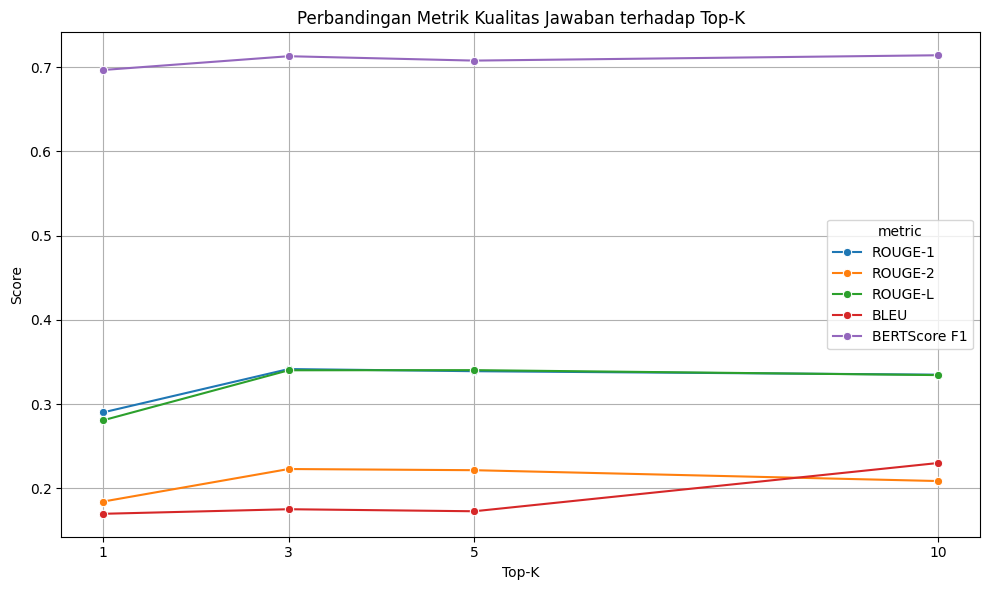

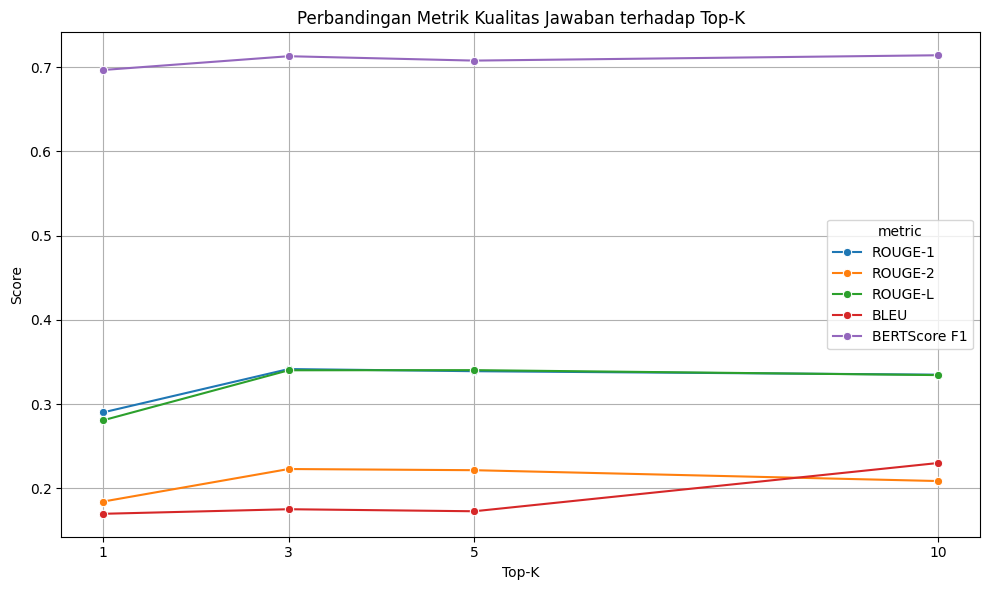

In [97]:
# Grafik ROUGE, BLEU, dan BERTScore terhadap nilai Top-K

combined_metric_df = final_eval_df.copy()

# BLEU dari sacrebleu berada pada skala 0-100, jadi dinormalisasi ke 0-1
combined_metric_df["bleu_normalized"] = combined_metric_df["bleu"] / 100

combined_plot_df = combined_metric_df.melt(
    id_vars="top_k",
    value_vars=[
        "rouge1",
        "rouge2",
        "rougeL",
        "bleu_normalized",
        "bertscore_f1"
    ],
    var_name="metric",
    value_name="score"
)

combined_plot_df["metric"] = combined_plot_df["metric"].replace({
    "rouge1": "ROUGE-1",
    "rouge2": "ROUGE-2",
    "rougeL": "ROUGE-L",
    "bleu_normalized": "BLEU",
    "bertscore_f1": "BERTScore F1"
})

plt.figure(figsize=(10, 6))
sns.lineplot(
    data=combined_plot_df,
    x="top_k",
    y="score",
    hue="metric",
    marker="o"
)

plt.title("Perbandingan Metrik Kualitas Jawaban terhadap Top-K")
plt.xlabel("Top-K")
plt.ylabel("Score")
plt.xticks(sorted(final_eval_df["top_k"].unique()))
plt.grid(True)

plt.tight_layout()
plt.savefig("outputs/figures/metric_vs_k.png", dpi=300)
plt.show()

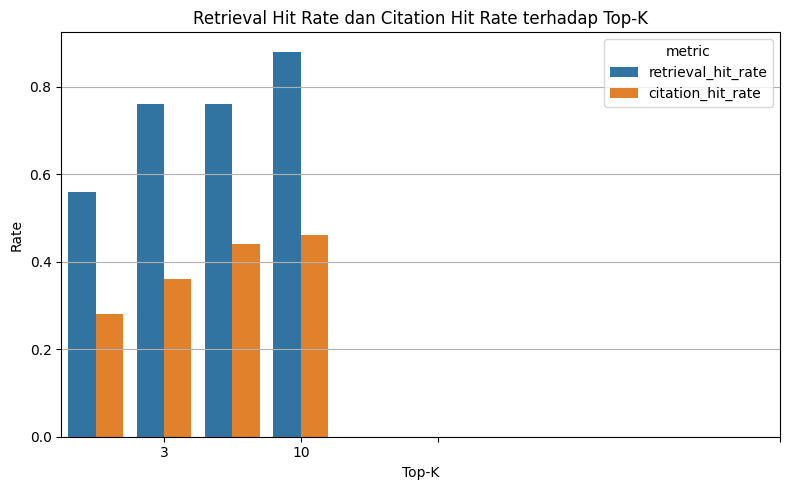

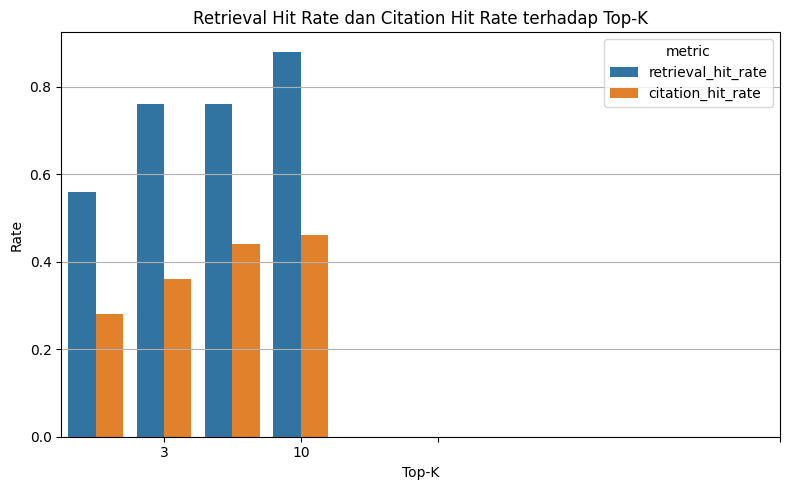

In [98]:
# Grafik retrieval hit rate dan citation hit rate terhadap nilai Top-K

citation_plot_df = final_eval_df.melt(
    id_vars="top_k",
    value_vars=["retrieval_hit_rate", "citation_hit_rate"],
    var_name="metric",
    value_name="score"
)

plt.figure(figsize=(8, 5))
sns.barplot(
    data=citation_plot_df,
    x="top_k",
    y="score",
    hue="metric"
)

plt.title("Retrieval Hit Rate dan Citation Hit Rate terhadap Top-K")
plt.xlabel("Top-K")
plt.ylabel("Rate")
plt.xticks(sorted(final_eval_df["top_k"].unique()))
plt.grid(axis="y")

plt.tight_layout()
plt.savefig("outputs/figures/retrieval_citation_hit_vs_k.png", dpi=300)
plt.show()

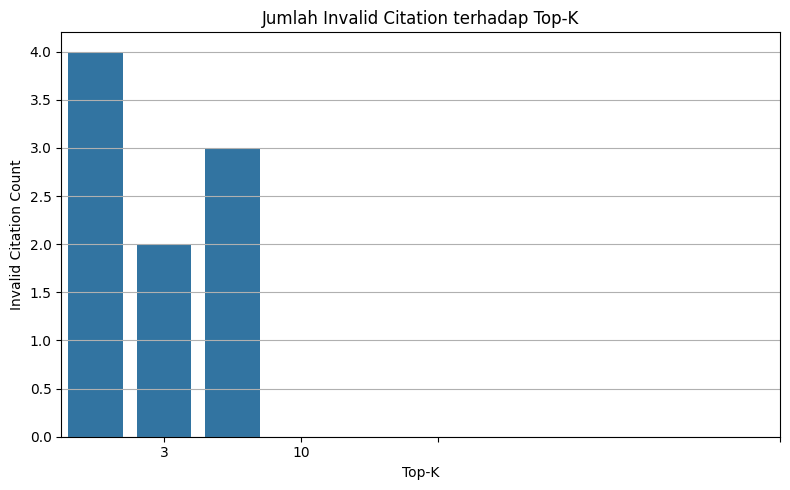

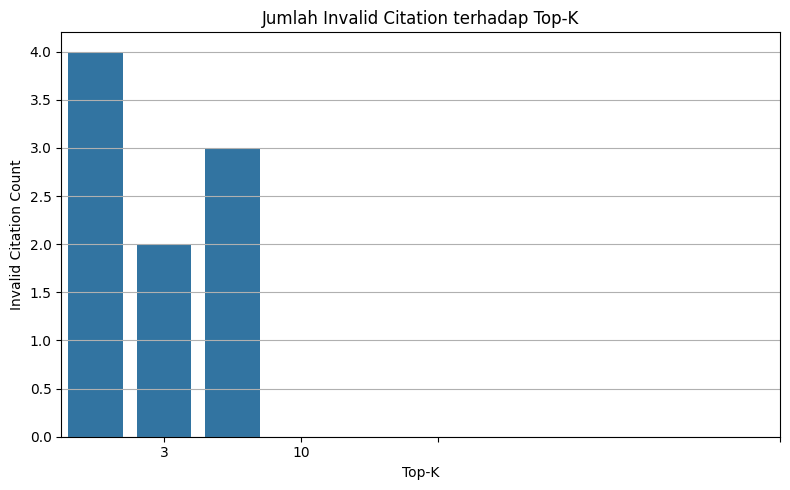

In [99]:
# Grafik jumlah invalid citation terhadap nilai Top-K

plt.figure(figsize=(8, 5))
sns.barplot(
    data=final_eval_df,
    x="top_k",
    y="invalid_citation_count"
)

plt.title("Jumlah Invalid Citation terhadap Top-K")
plt.xlabel("Top-K")
plt.ylabel("Invalid Citation Count")
plt.xticks(sorted(final_eval_df["top_k"].unique()))
plt.grid(axis="y")

plt.tight_layout()
plt.savefig("outputs/figures/invalid_citation_vs_k.png", dpi=300)
plt.show()

In [100]:
# Menampilkan tabel evaluasi akhir

display(
    final_eval_df.round(4)
        .sort_values("top_k")
        .reset_index(drop=True)
)

,top_k,rouge1,rouge2,rougeL,bleu,bertscore_f1,retrieval_hit_rate,citation_hit_rate,invalid_citation_count,no_citation_rate,citation_hallucination_rate
0,1,0.2901,0.1843,0.2807,16.9753,0.6966,0.56,0.28,4,0.42,0.72
1,3,0.3416,0.2229,0.3401,17.5177,0.7130,0.76,0.36,2,0.32,0.64
2,5,0.3390,0.2215,0.3403,17.2756,0.7078,0.76,0.44,3,0.24,0.56
3,10,0.3349,0.2086,0.3344,23.0064,0.7141,0.88,0.46,0,0.24,0.54


,top_k,rouge1,rouge2,rougeL,bleu,bertscore_f1,retrieval_hit_rate,citation_hit_rate,invalid_citation_count,no_citation_rate,citation_hallucination_rate
0,1,0.2901,0.1843,0.2807,16.9753,0.6966,0.56,0.28,4,0.42,0.72
1,3,0.3416,0.2229,0.3401,17.5177,0.7130,0.76,0.36,2,0.32,0.64
2,5,0.3390,0.2215,0.3403,17.2756,0.7078,0.76,0.44,3,0.24,0.56
3,10,0.3349,0.2086,0.3344,23.0064,0.7141,0.88,0.46,0,0.24,0.54
